In [1]:


from pathlib import Path
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor

plt.style.use("default")
pd.set_option("display.max_columns", 100)


In [2]:


# 1. Settings

TRAIN_DIR = Path("train_data")     # 2024 folders
TEST_DIR = Path("test_data")      # 2025 folders
FORCE_NAME = "city-of-london"

TRAIN_YEAR = 2024
TEST_YEAR = 2025




In [3]:


# 2. Load monthly CSV files

def load_year_from_folders(base_dir: Path, year: int, force_name: str = "city-of-london") -> pd.DataFrame:
    frames = []
    missing = []

    for month in range(1, 13):
        folder_name = f"{year}-{month:02d}"
        file_name = f"{folder_name}-{force_name}-street.csv"
        file_path = base_dir / folder_name / file_name

        if file_path.exists():
            temp = pd.read_csv(file_path)
            temp["source_file"] = str(file_path)
            frames.append(temp)
        else:
            missing.append(str(file_path))

    if missing:
        print(f"Missing {len(missing)} files for {year}.")
        for p in missing[:5]:
            print("  -", p)
        if len(missing) > 5:
            print("  ...")

    if not frames:
        raise FileNotFoundError(f"No CSV files found for {year} in {base_dir.resolve()}")

    out = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} files for {year}. Shape: {out.shape}")
    return out

train_raw = load_year_from_folders(TRAIN_DIR, TRAIN_YEAR, FORCE_NAME)
test_raw = load_year_from_folders(TEST_DIR, TEST_YEAR, FORCE_NAME)

raw_all = pd.concat([train_raw, test_raw], ignore_index=True)
raw_all.head()


Loaded 12 files for 2024. Shape: (9992, 13)
Loaded 12 files for 2025. Shape: (8875, 13)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,source_file
0,e7b720d0e1302d2d06db7b28b29132eb194864d44d7921...,2024-01,City of London Police,City of London Police,-0.106220,51.518275,On or near B500,E01000916,Camden 027B,Theft from the person,Investigation complete; no suspect identified,NaN,train_data/2024-01/2024-01-city-of-london-stre...
1,e60a5ac62a80e866453254474137c3206417422c62f0c0...,2024-01,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,E01000917,Camden 027C,Other theft,Investigation complete; no suspect identified,NaN,train_data/2024-01/2024-01-city-of-london-stre...
2,986f618142ec52b7f254e4b0549da2f17ceeb0e130db6c...,2024-01,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Other theft,Investigation complete; no suspect identified,NaN,train_data/2024-01/2024-01-city-of-london-stre...
3,05dc27a88748356f6d59b0bd1389710ebfb42b37e565af...,2024-01,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Theft from the person,Status update unavailable,NaN,train_data/2024-01/2024-01-city-of-london-stre...
4,373d78e2ccec5d05a547cd4bee19045a9e050042a0e6e7...,2024-01,City of London Police,City of London Police,-0.112096,51.515942,On or near Nightclub,E01000914,Camden 028B,Theft from the person,Investigation complete; no suspect identified,NaN,train_data/2024-01/2024-01-city-of-london-stre...


In [4]:


# 3. Aggregate to monthly counts

needed_cols = ["Month", "LSOA code", "LSOA name", "Crime type"]
missing_cols = [c for c in needed_cols if c not in raw_all.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Keep only rows with valid LSOA and crime type.

clean_raw = raw_all.dropna(subset=["Month", "LSOA code", "Crime type"]).copy()

monthly_counts = (
    clean_raw
    .groupby(["Month", "LSOA code", "LSOA name", "Crime type"])
    .size()
    .reset_index(name="crime_count")
)

monthly_counts["date"] = pd.to_datetime(monthly_counts["Month"] + "-01")
monthly_counts["year"] = monthly_counts["date"].dt.year
monthly_counts["month_num"] = monthly_counts["date"].dt.month

print("Aggregated shape:", monthly_counts.shape)
display(monthly_counts.head())


Aggregated shape: (2055, 8)


,Month,LSOA code,LSOA name,Crime type,crime_count,date,year,month_num
0,2024-01,E01000001,City of London 001A,Anti-social behaviour,2,2024-01-01,2024,1
1,2024-01,E01000001,City of London 001A,Burglary,1,2024-01-01,2024,1
2,2024-01,E01000001,City of London 001A,Drugs,1,2024-01-01,2024,1
3,2024-01,E01000001,City of London 001A,Other theft,3,2024-01-01,2024,1
4,2024-01,E01000001,City of London 001A,Public order,1,2024-01-01,2024,1


In [5]:


# 4. Build a complete monthly panel

# this creates explicit zero rows, so the model learns both crime and no-crime cases.

all_months = pd.date_range(
    monthly_counts["date"].min(),
    monthly_counts["date"].max(),
    freq="MS"
)

lsoa_lookup = (
    monthly_counts[["LSOA code", "LSOA name"]]
    .drop_duplicates("LSOA code")
    .sort_values("LSOA code")
)

crime_types = sorted(monthly_counts["Crime type"].dropna().unique())

full_index = pd.MultiIndex.from_product(
    [all_months, lsoa_lookup["LSOA code"], crime_types],
    names=["date", "LSOA code", "Crime type"]
).to_frame(index=False)

panel = full_index.merge(lsoa_lookup, on="LSOA code", how="left")
panel = panel.merge(
    monthly_counts[["date", "LSOA code", "Crime type", "crime_count"]],
    on=["date", "LSOA code", "Crime type"],
    how="left"
)

panel["crime_count"] = panel["crime_count"].fillna(0).astype(int)
panel["Month"] = panel["date"].dt.strftime("%Y-%m")
panel["year"] = panel["date"].dt.year
panel["month_num"] = panel["date"].dt.month

print("Complete panel shape:", panel.shape)
print("Date range:", panel["Month"].min(), "to", panel["Month"].max())
print("LSOAs:", panel["LSOA code"].nunique(), "| Crime types:", panel["Crime type"].nunique())
display(panel.head())


Complete panel shape: (66528, 8)
Date range: 2024-01 to 2025-12
LSOAs: 198 | Crime types: 14


,date,LSOA code,Crime type,LSOA name,crime_count,Month,year,month_num
0,2024-01-01,E01000001,Anti-social behaviour,City of London 001A,2,2024-01,2024,1
1,2024-01-01,E01000001,Bicycle theft,City of London 001A,0,2024-01,2024,1
2,2024-01-01,E01000001,Burglary,City of London 001A,1,2024-01,2024,1
3,2024-01-01,E01000001,Criminal damage and arson,City of London 001A,0,2024-01,2024,1
4,2024-01-01,E01000001,Drugs,City of London 001A,1,2024-01,2024,1


In [6]:


# 5. Add forecasting features

def add_forecasting_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["LSOA code", "Crime type", "date"]).copy()
    group_cols = ["LSOA code", "Crime type"]
    g = df.groupby(group_cols)["crime_count"]

    #  previous crime levels for the same LSOA and crime type
    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = g.shift(lag)

    df["rolling_3_mean"] = g.transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    df["rolling_6_mean"] = g.transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
    df["rolling_3_sum"] = g.transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
    df["rolling_6_sum"] = g.transform(lambda s: s.shift(1).rolling(6, min_periods=1).sum())

    # City-wide and crime-type context from previous month
    city_month_total = df.groupby("date")["crime_count"].sum().rename("city_total")
    crime_type_month_total = df.groupby(["date", "Crime type"])["crime_count"].sum().rename("crime_type_total")

    df = df.merge(city_month_total, on="date", how="left")
    df = df.merge(crime_type_month_total, on=["date", "Crime type"], how="left")

    df = df.sort_values(["LSOA code", "Crime type", "date"])
    df["city_total_lag_1"] = df.groupby(["LSOA code", "Crime type"])["city_total"].shift(1)
    df["crime_type_total_lag_1"] = df.groupby(["LSOA code", "Crime type"])["crime_type_total"].shift(1)

  
    df["quarter"] = df["date"].dt.quarter
    df["is_winter"] = df["month_num"].isin([12, 1, 2]).astype(int)
    df["is_summer"] = df["month_num"].isin([6, 7, 8]).astype(int)

    
    feature_cols_to_fill = [
        c for c in df.columns
        if c.startswith("lag_") or c.startswith("rolling_") or c.endswith("lag_1")
    ]
    df[feature_cols_to_fill] = df[feature_cols_to_fill].fillna(0)

    return df

model_df = add_forecasting_features(panel)

print("Model dataframe shape:", model_df.shape)
display(model_df.head())


Model dataframe shape: (66528, 24)


,date,LSOA code,Crime type,LSOA name,crime_count,Month,year,month_num,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3_mean,rolling_6_mean,rolling_3_sum,rolling_6_sum,city_total,crime_type_total,city_total_lag_1,crime_type_total_lag_1,quarter,is_winter,is_summer
0,2024-01-01,E01000001,Anti-social behaviour,City of London 001A,2,2024-01,2024,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,657,10,0.0,0.0,1,1,0
1,2024-02-01,E01000001,Anti-social behaviour,City of London 001A,0,2024-02,2024,2,2.0,0.0,0.0,0.0,0.0,2.000000,2.000000,2.0,2.0,764,31,657.0,10.0,1,1,0
2,2024-03-01,E01000001,Anti-social behaviour,City of London 001A,0,2024-03,2024,3,0.0,2.0,0.0,0.0,0.0,1.000000,1.000000,2.0,2.0,691,44,764.0,31.0,1,0,0
3,2024-04-01,E01000001,Anti-social behaviour,City of London 001A,0,2024-04,2024,4,0.0,0.0,2.0,0.0,0.0,0.666667,0.666667,2.0,2.0,831,31,691.0,44.0,2,0,0
4,2024-05-01,E01000001,Anti-social behaviour,City of London 001A,0,2024-05,2024,5,0.0,0.0,0.0,0.0,0.0,0.000000,0.500000,0.0,2.0,851,46,831.0,31.0,2,0,0


In [7]:

# 6. Train/validation/test split

# Train on 2024 and test on 2025.


VALIDATION_MONTHS = [10, 11, 12]

full_train_df = model_df[model_df["year"] == TRAIN_YEAR].copy()
test_df = model_df[model_df["year"] == TEST_YEAR].copy()

inner_train_df = full_train_df[~full_train_df["month_num"].isin(VALIDATION_MONTHS)].copy()
val_df = full_train_df[full_train_df["month_num"].isin(VALIDATION_MONTHS)].copy()

# Final models are still trained on all 2024 data.
train_df = full_train_df.copy()

print("Inner train rows:", len(inner_train_df), "| Validation rows:", len(val_df), "| Test rows:", len(test_df))
print("Inner train months:", inner_train_df["Month"].min(), "to", inner_train_df["Month"].max())
print("Validation months:", val_df["Month"].min(), "to", val_df["Month"].max())
print("Test months:", test_df["Month"].min(), "to", test_df["Month"].max())

# For categorical consistency in XGBoost
cat_categories = {}
for col in ["LSOA code", "Crime type"]:
    categories = sorted(model_df[col].astype(str).unique())
    cat_categories[col] = categories
    for frame in [inner_train_df, val_df, train_df, test_df]:
        frame[col] = pd.Categorical(frame[col].astype(str), categories=categories)

Inner train rows: 24948 | Validation rows: 8316 | Test rows: 33264
Inner train months: 2024-01 to 2024-09
Validation months: 2024-10 to 2024-12
Test months: 2025-01 to 2025-12


In [8]:


# 7. Metrics helper

def clip_predictions(pred):
    return np.clip(np.asarray(pred, dtype=float), 0, None)

def wape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom

def evaluate_model(name, y_true, y_pred):
    y_pred = clip_predictions(y_pred)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(np.asarray(y_true), y_pred),
        "Bias": np.mean(y_pred - np.asarray(y_true)),
        "Actual total": np.sum(y_true),
        "Predicted total": np.sum(y_pred),
    }


In [9]:

# 8. Model A: simple XGBoost benchmark



simple_features = ["month_num", "LSOA code", "Crime type"]

def prepare_xgb_frame(df, features):
    out = df[features].copy()
    for col in ["LSOA code", "Crime type"]:
        if col in out.columns:
            out[col] = pd.Categorical(out[col].astype(str), categories=cat_categories[col])
    return out

def make_simple_xgb():
    return xgb.XGBRegressor(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.0,
        objective="reg:squarederror",
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
    )

# Validation version: train on Jan-Sep 2024, validate on Oct-Dec 2024.
X_inner_simple = prepare_xgb_frame(inner_train_df, simple_features)
y_inner = inner_train_df["crime_count"].values
X_val_simple = prepare_xgb_frame(val_df, simple_features)
y_val = val_df["crime_count"].values

simple_xgb_val = make_simple_xgb()
simple_xgb_val.fit(X_inner_simple, y_inner)
pred_val_simple_xgb = clip_predictions(simple_xgb_val.predict(X_val_simple))

# Final benchmark version: train on all 2024, test on 2025.
X_train_simple = prepare_xgb_frame(train_df, simple_features)
y_train = train_df["crime_count"].values
X_test_simple = prepare_xgb_frame(test_df, simple_features)
y_test = test_df["crime_count"].values

simple_xgb = make_simple_xgb()
simple_xgb.fit(X_train_simple, y_train)
pred_simple_xgb = clip_predictions(simple_xgb.predict(X_test_simple))

print("Validation:", evaluate_model("Simple XGBoost", y_val, pred_val_simple_xgb))
print("Test:", evaluate_model("Simple XGBoost", y_test, pred_simple_xgb))

Validation: {'model': 'Simple XGBoost', 'MAE': np.float64(0.10084634215013674), 'RMSE': np.float64(0.9906500153088925), 'WAPE': np.float64(0.37590236724362935), 'Bias': np.float64(-0.013889051431538657), 'Actual total': np.int64(2231), 'Predicted total': np.float64(2115.4986482953245)}
Test: {'model': 'Simple XGBoost', 'MAE': np.float64(0.11338806352198627), 'RMSE': np.float64(0.9357620482204623), 'WAPE': np.float64(0.4571806721206486), 'Bias': np.float64(0.033677308595352555), 'Actual total': np.int64(8250), 'Predicted total': np.float64(9370.241993115807)}


In [10]:

# 9. Model B1: improved XGBoost with lag/rolling features
# previous crime levels, rolling trends, and city/crime-type context.

mixed_features = [
    "month_num", "quarter", "is_winter", "is_summer",
    "LSOA code", "Crime type",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "rolling_3_mean", "rolling_6_mean", "rolling_3_sum", "rolling_6_sum",
    "city_total_lag_1", "crime_type_total_lag_1",
]

def make_improved_xgb():
    return xgb.XGBRegressor(
        n_estimators=600,
        max_depth=3,
        learning_rate=0.025,
        subsample=0.9,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.10,
        reg_lambda=1.50,
        objective="count:poisson",   
        enable_categorical=True,
        tree_method="hist",
        random_state=42,
    )

# Validation version
X_inner_mixed_xgb = prepare_xgb_frame(inner_train_df, mixed_features)
X_val_mixed_xgb = prepare_xgb_frame(val_df, mixed_features)

improved_xgb_val = make_improved_xgb()
improved_xgb_val.fit(X_inner_mixed_xgb, y_inner)
pred_val_improved_xgb = clip_predictions(improved_xgb_val.predict(X_val_mixed_xgb))

# Final version
X_train_mixed_xgb = prepare_xgb_frame(train_df, mixed_features)
X_test_mixed_xgb = prepare_xgb_frame(test_df, mixed_features)

improved_xgb = make_improved_xgb()
improved_xgb.fit(X_train_mixed_xgb, y_train)
pred_improved_xgb = clip_predictions(improved_xgb.predict(X_test_mixed_xgb))

print("Validation:", evaluate_model("Improved XGBoost", y_val, pred_val_improved_xgb))
print("Test:", evaluate_model("Improved XGBoost", y_test, pred_improved_xgb))

Validation: {'model': 'Improved XGBoost', 'MAE': np.float64(0.09644714748208745), 'RMSE': np.float64(1.0295346509780923), 'WAPE': np.float64(0.35950447264053753), 'Bias': np.float64(-0.012355780014242443), 'Actual total': np.int64(2231), 'Predicted total': np.float64(2128.24933340156)}
Test: {'model': 'Improved XGBoost', 'MAE': np.float64(0.10712886486186338), 'RMSE': np.float64(1.0656546311447617), 'WAPE': np.float64(0.43194358312303316), 'Bias': np.float64(0.03456610582340115), 'Actual total': np.int64(8250), 'Predicted total': np.float64(9399.806944109616)}


In [11]:

# 10. Model B2: Poisson count model


categorical_features = ["LSOA code", "Crime type"]
numeric_features = [c for c in mixed_features if c not in categorical_features]

def make_poisson_pipeline(alpha=0.5):
    # Compatibility for different sklearn versions
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    poisson_preprocess = ColumnTransformer(
        transformers=[
            ("cat", onehot, categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )

    return Pipeline(steps=[
        ("preprocess", poisson_preprocess),
        ("model", PoissonRegressor(alpha=alpha, max_iter=2000)),
    ])

def prepare_sklearn_frame(df, features):
    out = df[features].copy()
    for col in categorical_features:
        out[col] = out[col].astype(str)
    return out

# Validation version
X_inner_poisson = prepare_sklearn_frame(inner_train_df, mixed_features)
X_val_poisson = prepare_sklearn_frame(val_df, mixed_features)

poisson_model_val = make_poisson_pipeline(alpha=0.5)
poisson_model_val.fit(X_inner_poisson, y_inner)
pred_val_poisson = clip_predictions(poisson_model_val.predict(X_val_poisson))

# Final version
X_train_poisson = prepare_sklearn_frame(train_df, mixed_features)
X_test_poisson = prepare_sklearn_frame(test_df, mixed_features)

poisson_model = make_poisson_pipeline(alpha=0.5)
poisson_model.fit(X_train_poisson, y_train)
pred_poisson = clip_predictions(poisson_model.predict(X_test_poisson))

print("Validation:", evaluate_model("Poisson count model", y_val, pred_val_poisson))
print("Test:", evaluate_model("Poisson count model", y_test, pred_poisson))

Validation: {'model': 'Poisson count model', 'MAE': np.float64(0.3674807419723519), 'RMSE': np.float64(5.039996152270656), 'WAPE': np.float64(1.3697758181273325), 'Bias': np.float64(0.034378213439770045), 'Actual total': np.int64(2231), 'Predicted total': np.float64(2516.889222965128)}
Test: {'model': 'Poisson count model', 'MAE': np.float64(0.3461856195015978), 'RMSE': np.float64(3.4092925018715015), 'WAPE': np.float64(1.3958204178304423), 'Bias': np.float64(-0.00016274720181182043), 'Actual total': np.int64(8250), 'Predicted total': np.float64(8244.586377078931)}


In [12]:

# 11. Model B3: rolling baseline



def rolling_baseline_prediction(df):
    return clip_predictions(
        df["rolling_3_mean"].fillna(df["lag_1"]).fillna(0).values
    )

pred_val_rolling_baseline = rolling_baseline_prediction(val_df)
pred_rolling_baseline = rolling_baseline_prediction(test_df)

print("Validation:", evaluate_model("Rolling baseline", y_val, pred_val_rolling_baseline))
print("Test:", evaluate_model("Rolling baseline", y_test, pred_rolling_baseline))

Validation: {'model': 'Rolling baseline', 'MAE': np.float64(0.0962000962000962), 'RMSE': np.float64(0.9356964061150673), 'WAPE': np.float64(0.35858359480053786), 'Bias': np.float64(8.016674683341322e-05), 'Actual total': np.int64(2231), 'Predicted total': np.float64(2231.6666666666665)}
Test: {'model': 'Rolling baseline', 'MAE': np.float64(0.09051827801827801), 'RMSE': np.float64(0.8694379324726512), 'WAPE': np.float64(0.36496969696969694), 'Bias': np.float64(0.0002505210838544168), 'Actual total': np.int64(8250), 'Predicted total': np.float64(8258.333333333336)}


In [13]:

# 12. Build mixed ensemble



# Old fixed weights kept for comparison only.
W_XGB_FIXED = 0.80
W_POISSON_FIXED = 0.10
W_BASELINE_FIXED = 0.10

pred_mixed_pipeline_fixed = clip_predictions(
    W_XGB_FIXED * pred_improved_xgb +
    W_POISSON_FIXED * pred_poisson +
    W_BASELINE_FIXED * pred_rolling_baseline
)

pred_val_mixed_fixed = clip_predictions(
    W_XGB_FIXED * pred_val_improved_xgb +
    W_POISSON_FIXED * pred_val_poisson +
    W_BASELINE_FIXED * pred_val_rolling_baseline
)

# Validation-based ensemble search.
# XGBoost is allowed to dominate because the row-level data is sparse and nonlinear.
weight_results = []
for w_xgb in np.arange(0.50, 0.96, 0.05):
    for w_poisson in np.arange(0.00, 0.41, 0.05):
        w_baseline = 1.0 - w_xgb - w_poisson
        if w_baseline < -1e-9:
            continue

        pred_val_candidate = clip_predictions(
            w_xgb * pred_val_improved_xgb +
            w_poisson * pred_val_poisson +
            w_baseline * pred_val_rolling_baseline
        )

        result = evaluate_model("candidate", y_val, pred_val_candidate)
        result.update({
            "w_xgb": round(float(w_xgb), 2),
            "w_poisson": round(float(w_poisson), 2),
            "w_baseline": round(float(w_baseline), 2),
        })
        weight_results.append(result)

weight_results = pd.DataFrame(weight_results)
weight_results = weight_results.sort_values(["WAPE", "MAE", "RMSE"]).reset_index(drop=True)

best_weights = weight_results.iloc[0]
W_XGB = float(best_weights["w_xgb"])
W_POISSON = float(best_weights["w_poisson"])
W_BASELINE = float(best_weights["w_baseline"])

print("Best validation weights:")
print({"Improved XGBoost": W_XGB, "Poisson": W_POISSON, "Rolling baseline": W_BASELINE})
print("\nTop 10 validation weight combinations:")
display(weight_results.head(10))

# Optional level calibration learned on validation only.
# This corrects systematic over/under-prediction in total volume while avoiding extreme scaling.
pred_val_tuned_uncalibrated = clip_predictions(
    W_XGB * pred_val_improved_xgb +
    W_POISSON * pred_val_poisson +
    W_BASELINE * pred_val_rolling_baseline
)

raw_calibration_factor = np.sum(y_val) / max(np.sum(pred_val_tuned_uncalibrated), 1e-9)
CALIBRATION_FACTOR = float(np.clip(raw_calibration_factor, 0.70, 1.30))
print("Validation calibration factor:", CALIBRATION_FACTOR)

pred_mixed_pipeline_uncalibrated = clip_predictions(
    W_XGB * pred_improved_xgb +
    W_POISSON * pred_poisson +
    W_BASELINE * pred_rolling_baseline
)

pred_mixed_pipeline = clip_predictions(pred_mixed_pipeline_uncalibrated * CALIBRATION_FACTOR)

metrics = pd.DataFrame([
    evaluate_model("Simple XGBoost", y_test, pred_simple_xgb),
    evaluate_model("Improved XGBoost", y_test, pred_improved_xgb),
    evaluate_model("Poisson count model", y_test, pred_poisson),
    evaluate_model("Rolling baseline", y_test, pred_rolling_baseline),
    evaluate_model("Mixed pipeline fixed weights", y_test, pred_mixed_pipeline_fixed),
    evaluate_model("Mixed pipeline tuned", y_test, pred_mixed_pipeline),
])

# Make WAPE easier to read as percentage
metrics_display = metrics.copy()
metrics_display["WAPE"] = metrics_display["WAPE"] * 100

metrics_display.sort_values("MAE")

Best validation weights:
{'Improved XGBoost': 0.5, 'Poisson': 0.0, 'Rolling baseline': 0.5}

Top 10 validation weight combinations:


,model,MAE,RMSE,WAPE,Bias,Actual total,Predicted total,w_xgb,w_poisson,w_baseline
0,candidate,0.092124,0.937352,0.343391,-0.006138,2231,2179.958000,0.50,0.0,0.50
1,candidate,0.092287,0.942731,0.343996,-0.006760,2231,2174.787133,0.55,0.0,0.45
2,candidate,0.092610,0.949018,0.345202,-0.007381,2231,2169.616267,0.60,0.0,0.40
3,candidate,0.092996,0.956196,0.346641,-0.008003,2231,2164.445400,0.65,0.0,0.35
4,candidate,0.093399,0.964245,0.348142,-0.008625,2231,2159.274533,0.70,0.0,0.30
5,candidate,0.093828,0.973144,0.349742,-0.009247,2231,2154.103667,0.75,0.0,0.25
6,candidate,0.094288,0.982869,0.351455,-0.009869,2231,2148.932800,0.80,0.0,0.20
7,candidate,0.094757,0.993396,0.353204,-0.010490,2231,2143.761933,0.85,0.0,0.15
8,candidate,0.095280,1.004700,0.355155,-0.011112,2231,2138.591067,0.90,0.0,0.10
9,candidate,0.095831,1.016755,0.357208,-0.011734,2231,2133.420200,0.95,0.0,0.05


Validation calibration factor: 1.023414212551383


,model,MAE,RMSE,WAPE,Bias,Actual total,Predicted total
3,Rolling baseline,0.090518,0.869438,36.496970,0.000251,8250,8258.333333
5,Mixed pipeline tuned,0.096333,0.934677,38.841504,0.023623,8250,9035.795864
1,Improved XGBoost,0.107129,1.065655,43.194358,0.034566,8250,9399.806944
4,Mixed pipeline fixed weights,0.111948,1.027951,45.137476,0.027662,8250,9170.137526
0,Simple XGBoost,0.113388,0.935762,45.718067,0.033677,8250,9370.241993
2,Poisson count model,0.346186,3.409293,139.582042,-0.000163,8250,8244.586377


In [14]:

# 13. Create one comparison results dataframe

results_df = test_df[["Month", "date", "month_num", "LSOA code", "LSOA name", "Crime type", "crime_count"]].copy()
results_df = results_df.rename(columns={"crime_count": "Actual"})

results_df["Simple XGBoost"] = pred_simple_xgb
results_df["Improved XGBoost"] = pred_improved_xgb
results_df["Poisson"] = pred_poisson
results_df["Rolling baseline"] = pred_rolling_baseline
results_df["Mixed pipeline fixed weights"] = pred_mixed_pipeline_fixed
results_df["Mixed pipeline"] = pred_mixed_pipeline

results_df["Simple XGBoost Error"] = results_df["Simple XGBoost"] - results_df["Actual"]
results_df["Mixed pipeline Error"] = results_df["Mixed pipeline"] - results_df["Actual"]

# Rounded predictions for dashboard-style tables.
# Keep continuous predictions for evaluation; rounded values are only for display.
results_df["Simple XGBoost rounded"] = np.round(results_df["Simple XGBoost"]).astype(int)
results_df["Mixed pipeline rounded"] = np.round(results_df["Mixed pipeline"]).astype(int)

results_df.head(10)

,Month,date,month_num,LSOA code,LSOA name,Crime type,Actual,Simple XGBoost,Improved XGBoost,Poisson,Rolling baseline,Mixed pipeline fixed weights,Mixed pipeline,Simple XGBoost Error,Mixed pipeline Error,Simple XGBoost rounded,Mixed pipeline rounded
12,2025-01,2025-01-01,1,E01000001,City of London 001A,Anti-social behaviour,0,0.442349,0.286971,0.161202,0.000000,0.245697,0.146845,0.442349,0.146845,0,0
13,2025-02,2025-02-01,2,E01000001,City of London 001A,Anti-social behaviour,0,0.445639,0.142449,0.162303,0.000000,0.130189,0.072892,0.445639,0.072892,0,0
14,2025-03,2025-03-01,3,E01000001,City of London 001A,Anti-social behaviour,1,0.442489,0.145819,0.155294,0.000000,0.132185,0.074617,-0.557511,-0.925383,0,0
15,2025-04,2025-04-01,4,E01000001,City of London 001A,Anti-social behaviour,2,0.462425,0.199295,0.150728,0.333333,0.207842,0.272550,-1.537575,-1.727450,0,0
16,2025-05,2025-05-01,5,E01000001,City of London 001A,Anti-social behaviour,1,0.468163,0.269524,0.153653,1.000000,0.330985,0.649625,-0.531837,-0.350375,0,1
17,2025-06,2025-06-01,6,E01000001,City of London 001A,Anti-social behaviour,0,0.452185,0.288617,0.151620,1.333333,0.379389,0.829963,0.452185,0.829963,0,1
18,2025-07,2025-07-01,7,E01000001,City of London 001A,Anti-social behaviour,0,0.450035,0.250625,0.147486,1.000000,0.315248,0.639954,0.450035,0.639954,0,1
19,2025-08,2025-08-01,8,E01000001,City of London 001A,Anti-social behaviour,0,0.467416,0.239021,0.142427,0.333333,0.238792,0.292878,0.467416,0.292878,0,0
20,2025-09,2025-09-01,9,E01000001,City of London 001A,Anti-social behaviour,0,0.346535,0.232220,0.140016,0.000000,0.199777,0.118829,0.346535,0.118829,0,0
21,2025-10,2025-10-01,10,E01000001,City of London 001A,Anti-social behaviour,1,0.503384,0.240910,0.136523,0.000000,0.206381,0.123276,-0.496616,-0.876724,1,0


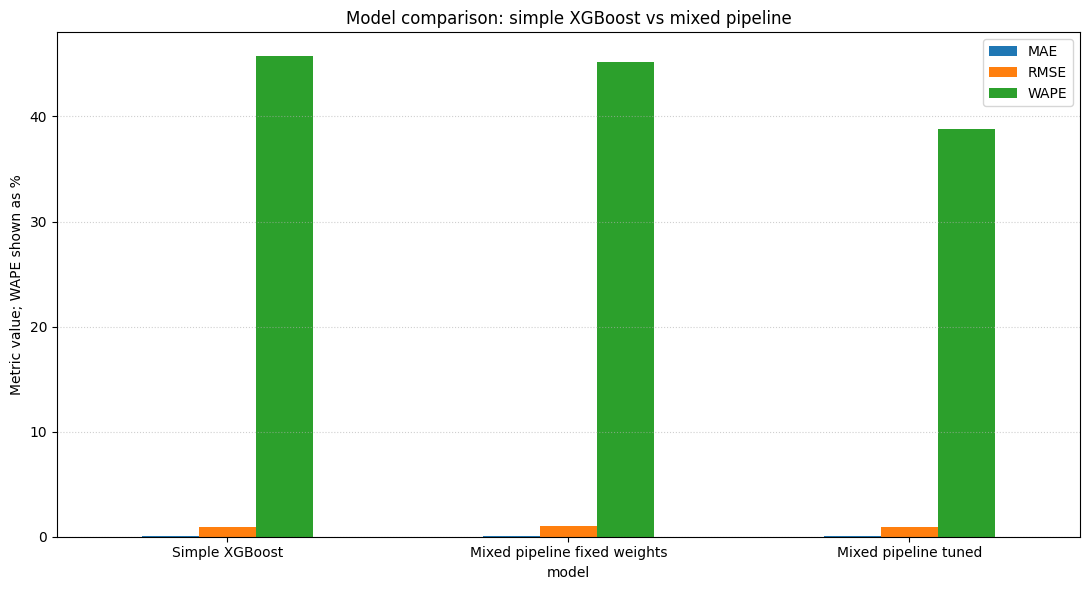

,MAE,RMSE,WAPE
model,,,
Simple XGBoost,0.113388,0.935762,45.718067
Mixed pipeline fixed weights,0.111948,1.027951,45.137476
Mixed pipeline tuned,0.096333,0.934677,38.841504


In [15]:
# -----------------------------
# 14. Visualization 1: metric comparison
# -----------------------------
plot_metrics = metrics_display.set_index("model").loc[
    ["Simple XGBoost", "Mixed pipeline fixed weights", "Mixed pipeline tuned"],
    ["MAE", "RMSE", "WAPE"]
]

ax = plot_metrics.plot(kind="bar", figsize=(11, 6), rot=0)
ax.set_title("Model comparison: simple XGBoost vs mixed pipeline")
ax.set_ylabel("Metric value; WAPE shown as %")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

plot_metrics

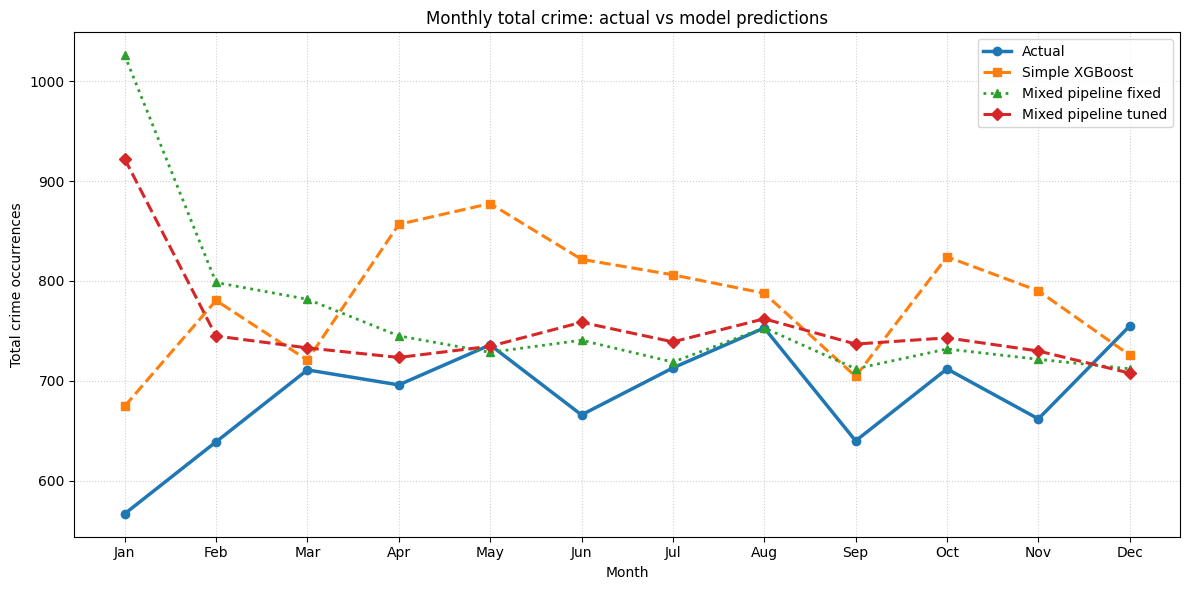

,month_num,Actual,Simple XGBoost,Mixed pipeline fixed weights,Mixed pipeline
0,1,567,674.634679,1025.890475,922.200164
1,2,639,780.529444,798.497208,744.932519
2,3,711,720.821647,781.722993,733.023998
3,4,696,856.672837,745.065905,723.455903
4,5,736,877.485145,728.568567,734.661418
5,6,666,821.676289,740.718034,758.683610
6,7,713,806.128988,718.815981,739.045670
7,8,753,787.712153,753.078207,762.135587
8,9,640,704.486656,712.140300,736.873390
9,10,712,824.189752,731.946186,743.077536


In [16]:
# -----------------------------
# 15. Visualization 2: monthly totals
# -----------------------------
monthly_summary = (
    results_df
    .groupby("month_num")[["Actual", "Simple XGBoost", "Mixed pipeline fixed weights", "Mixed pipeline"]]
    .sum()
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_summary["month_num"], monthly_summary["Actual"], marker="o", linewidth=2.5, label="Actual")
ax.plot(monthly_summary["month_num"], monthly_summary["Simple XGBoost"], marker="s", linestyle="--", linewidth=2.2, label="Simple XGBoost")
ax.plot(monthly_summary["month_num"], monthly_summary["Mixed pipeline fixed weights"], marker="^", linestyle=":", linewidth=2.0, label="Mixed pipeline fixed")
ax.plot(monthly_summary["month_num"], monthly_summary["Mixed pipeline"], marker="D", linestyle="--", linewidth=2.2, label="Mixed pipeline tuned")

ax.set_title("Monthly total crime: actual vs model predictions")
ax.set_xlabel("Month")
ax.set_ylabel("Total crime occurrences")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

monthly_summary

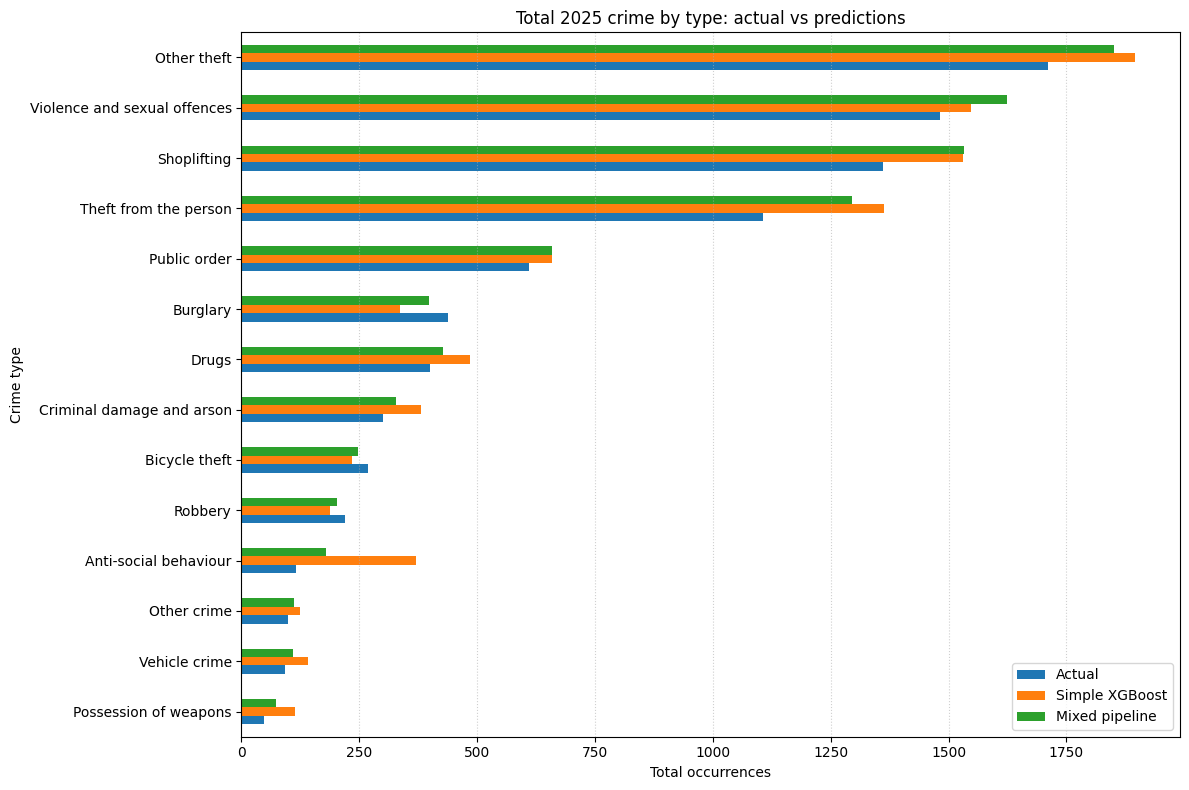

,Actual,Simple XGBoost,Mixed pipeline
Crime type,,,
Possession of weapons,48,114.229655,73.049086
Vehicle crime,93,141.111261,108.859747
Other crime,99,124.788808,112.185435
Anti-social behaviour,115,369.568244,178.482907
Robbery,220,188.424850,202.222424
Bicycle theft,268,234.711029,246.839947
Criminal damage and arson,300,380.077345,327.969033
Drugs,399,484.974263,426.606136
Burglary,439,336.328997,397.462338


In [17]:

# 16. Visualization 3: totals by crime type

crime_summary = (
    results_df
    .groupby("Crime type")[["Actual", "Simple XGBoost", "Mixed pipeline"]]
    .sum()
    .sort_values("Actual", ascending=True)
)

ax = crime_summary.plot(kind="barh", figsize=(12, 8))
ax.set_title("Total 2025 crime by type: actual vs predictions")
ax.set_xlabel("Total occurrences")
ax.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

crime_summary

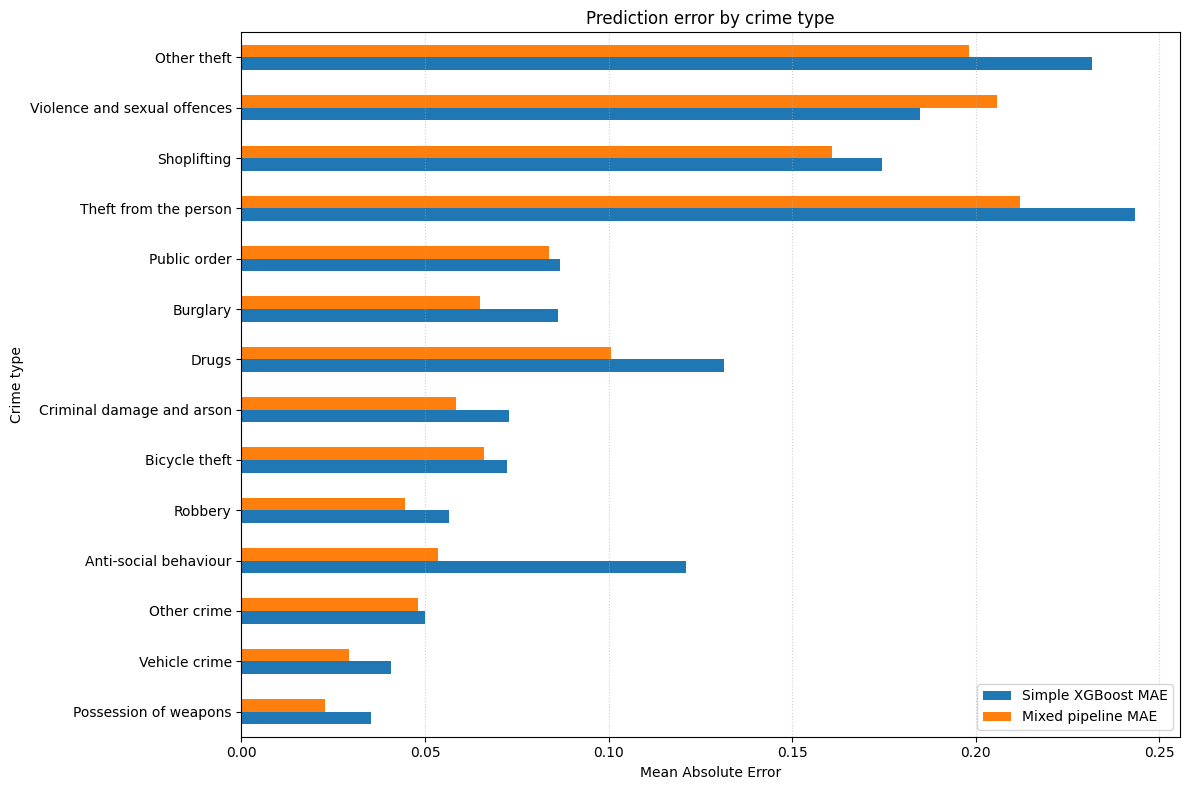

,Simple XGBoost MAE,Mixed pipeline MAE,Actual total
Crime type,,,
Possession of weapons,0.035238,0.022895,48.0
Vehicle crime,0.040658,0.029177,93.0
Other crime,0.050056,0.048004,99.0
Anti-social behaviour,0.121076,0.053569,115.0
Robbery,0.056448,0.044467,220.0
Bicycle theft,0.072424,0.066050,268.0
Criminal damage and arson,0.072892,0.058427,300.0
Drugs,0.131361,0.100539,399.0
Burglary,0.086111,0.064890,439.0


In [18]:

# 17. Visualization 4: error by crime type

error_by_crime = results_df.groupby("Crime type").apply(
    lambda d: pd.Series({
        "Simple XGBoost MAE": mean_absolute_error(d["Actual"], d["Simple XGBoost"]),
        "Mixed pipeline MAE": mean_absolute_error(d["Actual"], d["Mixed pipeline"]),
        "Actual total": d["Actual"].sum(),
    })
).sort_values("Actual total", ascending=True)

ax = error_by_crime[["Simple XGBoost MAE", "Mixed pipeline MAE"]].plot(kind="barh", figsize=(12, 8))
ax.set_title("Prediction error by crime type")
ax.set_xlabel("Mean Absolute Error")
ax.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

error_by_crime

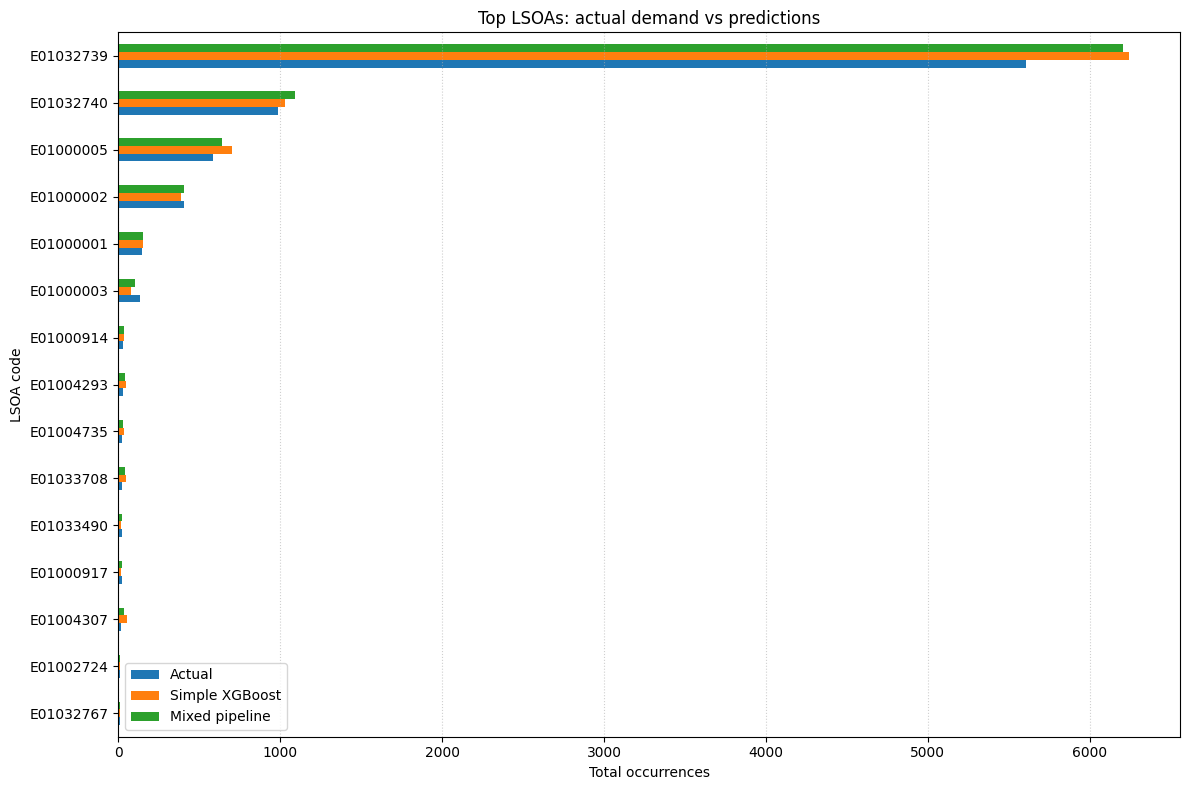

,Actual,Simple XGBoost,Mixed pipeline
LSOA code,,,
E01032767,11,7.507721,8.820350
E01002724,12,11.204778,12.403829
E01004307,19,50.424293,35.697248
E01000917,20,18.893405,20.739060
E01033490,24,15.579428,22.356571
E01033708,24,44.424239,38.914200
E01004735,25,33.210217,29.907853
E01004293,30,47.993340,41.204215
E01000914,31,34.331730,34.930675


In [19]:

# 18. Visualization 5: top LSOAs by actual demand

top_lsoas = results_df.groupby("LSOA code")["Actual"].sum().nlargest(15).index

lsoa_summary = (
    results_df[results_df["LSOA code"].isin(top_lsoas)]
    .groupby("LSOA code")[["Actual", "Simple XGBoost", "Mixed pipeline"]]
    .sum()
    .sort_values("Actual", ascending=True)
)

ax = lsoa_summary.plot(kind="barh", figsize=(12, 8))
ax.set_title("Top LSOAs: actual demand vs predictions")
ax.set_xlabel("Total occurrences")
ax.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

lsoa_summary

In [20]:

# 19. Dashboard-ready output

# Priority score: simple resource allocation example.


severity_weights = {
    "Violence and sexual offences": 3.0,
    "Robbery": 3.0,
    "Possession of weapons": 3.0,
    "Burglary": 2.0,
    "Vehicle crime": 1.5,
    "Drugs": 1.5,
    "Theft from the person": 1.5,
    "Other theft": 1.0,
    "Shoplifting": 1.0,
    "Public order": 1.0,
    "Criminal damage and arson": 1.0,
    "Bicycle theft": 1.0,
    "Other crime": 1.0,
}

dashboard_df = results_df.copy()
dashboard_df["severity_weight"] = dashboard_df["Crime type"].map(severity_weights).fillna(1.0)
dashboard_df["priority_score"] = dashboard_df["Mixed pipeline"] * dashboard_df["severity_weight"]

dashboard_df["risk_level"] = pd.qcut(
    dashboard_df["priority_score"].rank(method="first"),
    q=3,
    labels=["Low", "Medium", "High"]
)

export_cols = [
    "Month", "LSOA code", "LSOA name", "Crime type", "Actual",
    "Simple XGBoost", "Mixed pipeline",
    "Simple XGBoost rounded", "Mixed pipeline rounded",
    "severity_weight", "priority_score", "risk_level"
]

dashboard_export = dashboard_df[export_cols].sort_values(["Month", "priority_score"], ascending=[True, False])

output_path = "forecast_comparison_dashboard_output.csv"
dashboard_export.to_csv(output_path, index=False)
print(f"Saved dashboard output to: {output_path}")

dashboard_export.head(20)

Saved dashboard output to: forecast_comparison_dashboard_output.csv


,Month,LSOA code,LSOA name,Crime type,Actual,Simple XGBoost,Mixed pipeline,Simple XGBoost rounded,Mixed pipeline rounded,severity_weight,priority_score,risk_level
55092,2025-01,E01032739,City of London 001F,Violence and sexual offences,72,79.995071,110.276955,80,110,3.0,330.830864,High
54924,2025-01,E01032739,City of London 001F,Other theft,101,99.394341,135.073178,99,135,1.0,135.073178,High
55044,2025-01,E01032739,City of London 001F,Theft from the person,52,62.288979,85.768269,62,86,1.5,128.652404,High
55020,2025-01,E01032739,City of London 001F,Shoplifting,75,91.559990,117.232408,92,117,1.0,117.232408,High
55428,2025-01,E01032740,City of London 001G,Violence and sexual offences,8,12.594797,15.912403,13,16,3.0,47.737210,High
1332,2025-01,E01000005,City of London 001E,Violence and sexual offences,9,10.703993,14.436211,11,14,3.0,43.308634,High
54972,2025-01,E01032739,City of London 001F,Public order,28,30.576403,41.564578,31,42,1.0,41.564578,High
54876,2025-01,E01032739,City of London 001F,Drugs,21,19.542948,26.700117,20,27,1.5,40.050175,High
54828,2025-01,E01032739,City of London 001F,Burglary,14,9.711233,19.024362,10,19,2.0,38.048723,High
55380,2025-01,E01032740,City of London 001G,Theft from the person,11,15.849083,24.896416,16,25,1.5,37.344624,High
